### EDA absentismo laboral (dataset RRHH)

In [1]:
"""
Carga de datos
"""
# Importa todas las bibliotecas necesarias para este NoteBook
import pandas  as pd
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt
from EDA_helpers import load_tables, \
                        categorizar_ausentismo, \
                        categorizar_ausencias,  \
                        categorizar_distancias

tablas_db = ['ausentismo', 'long_absence']

# Paleta de colores Seaborn Set2, para usarla con MatPlotLib y seguir el mismo estilo
sns_color_set2 = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f", "#e5c494", "#b3b3b3"]
colores = sns_color_set2

df = load_tables(tablas_db)

# Extrae los dataframes del diccionario que devuelve `load_tables()`
for t in df:
    globals()[f'df_{t}'] = df[t]

Cargando los datos de la tabla ausentismo
Cargando los datos de la tabla long_absence


In [ ]:
# Categorizar las columnas Month_absence, Day_of_week y Season.
df_ausentismo = categorizar_ausentismo(df_ausentismo)
# Clasificar las ausencias en dos categorías (Justificada / Injustificada)
df_ausentismo = categorizar_ausencias(df_ausentismo)
# Clasificar las distancias al trabajo, en franjas de kms.
df_ausentismo = categorizar_distancias(df_ausentismo)

del globals()['df_long_absence']
df_niveles = df['long_absence']

df_niveles.head()

,id,reason_id,absence_reason,justified,Absenteeism_hours,Month_absence_num,Month_absence,Day_week,Day_of_week,Season,...,Social_drinker,Social_smoker,children,pets,weight,height,bmi,Group,Absence_type,distance_categories
0,14,11,Diseases of the digestive system,1,120,11,November,2,Monday,Spring,...,1,0,2,0,95,196,25,26-35,Justified,entre 10 y 20 km
1,36,13,Diseases of the musculoskeletal system and con...,1,120,4,April,4,Wednesday,Winter,...,1,0,1,0,98,178,31,46-54,Justified,entre 10 y 20 km
2,9,6,Diseases of the nervous system,1,120,7,July,3,Tuesday,Summer,...,0,0,2,1,65,172,22,55-65,Justified,entre 10 y 20 km
3,28,9,Diseases of the circulatory system,1,112,7,July,3,Tuesday,Summer,...,0,0,1,2,69,169,24,26-35,Justified,entre 21 y 30 km
4,9,12,Diseases of the skin and subcutaneous tissue,1,112,3,March,3,Tuesday,Autumn,...,0,0,2,1,65,172,22,55-65,Justified,entre 10 y 20 km


In [4]:
# Exportamos el DF a un archivo .csv para luego utilizarlo en el análisis de KPI's.
df_ausentismo.to_csv('RRHH_20251124.csv')

#### Descripción estadística

In [4]:
#Resumen estadístico inicial
df_ausentismo.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,1106.0,78.991863,106.513742,1.000,14.000,28.000,108.750,386.000
reason_id,1106.0,19.163653,8.324058,0.000,13.000,23.000,26.000,28.000
justified,1106.0,0.904159,0.294506,0.000,1.000,1.000,1.000,1.000
Absenteeism_hours,1106.0,8.625678,18.039349,0.000,2.000,3.000,8.000,120.000
Month_absence_num,1106.0,6.356239,3.443617,1.000,3.000,6.000,10.000,12.000
Day_week,1106.0,3.912297,1.416928,2.000,3.000,4.000,5.000,6.000
tr_expense,1106.0,221.972875,67.153887,118.000,179.000,225.000,260.000,388.000
dist2work,1106.0,29.395118,14.805842,5.000,16.000,26.000,50.000,52.000
Service_time,1106.0,12.493671,4.391112,1.000,9.000,12.000,16.000,29.000
work_load_avg,1106.0,272.049706,39.163773,205.917,244.387,264.604,294.217,378.884


In [5]:
# Distribución de datos categóricos
df_ausentismo_cat = df_ausentismo.select_dtypes(exclude=np.number)
df_ausentismo_cat.describe().transpose()

,count,unique,top,freq
absence_reason,1106,28,medical consultation,213
Month_absence,1106,12,March,127
Day_of_week,1106,5,Tuesday,238
Season,1106,4,Spring,294
Group,1106,4,36-45,533
Absence_type,1106,2,Justified,1000
distance_categories,1106,6,entre 10 y 20 km,338


In [6]:
#Agrupar por 'absence_reason' para determinar los motivos más frecuentes de absentismo laboral.
df_ausencias_razon = df_ausentismo \
                        .groupby('absence_reason')['reason_id'] \
                        .count() \
                        .sort_values(ascending=False)
df_ausencias_razon

absence_reason
medical consultation                                                                                   213
dental consultation                                                                                    173
physiotherapy                                                                                           96
Diseases of the musculoskeletal system and connective tissue                                            88
Injury, poisoning and certain other consequences of external causes                                     65
Unknown                                                                                                 56
Patient fol-up                                                                                          56
unjustified absence                                                                                     50
laboratory examination                                                                                  44
Diseases of the digest

In [40]:
# Cantidad de total de horas de ausencias por ID empleado
cantidad_ausencias = (
	df_ausentismo
		.groupby('id')['Absenteeism_hours']
		.sum() \
        .sort_values(ascending=False)
)
cantidad_ausencias

id
14     844
9      726
36     631
28     571
11     554
      ... 
251      0
262      0
141      0
154      0
292      0
Name: Absenteeism_hours, Length: 383, dtype: int64

In [7]:
# Calcular el total de absentismo por Mes

total_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['id'].count()
total_por_mes

Month_absence
January       83
February     103
March        127
April         79
May          100
June          70
July         110
August        79
September     76
October      109
November      92
December      78
Name: id, dtype: int64

In [42]:
#Calcular la media de absentismo por mes

# 1. Calcular la media de Absenteeism_hours por Month_absence
media_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['Absenteeism_hours'].mean().reset_index()

# 2. Eliminar meses que no están presentes en los datos (si aplica) y ordenar
media_h_por_mes = media_por_mes.dropna(subset=['Month_absence'])

# 3. Formatear la media a dos decimales
media_h_por_mes['Absenteeism_hours'] = media_h_por_mes['Absenteeism_hours'].round(2)
media_h_por_mes

,Month_absence,Absenteeism_hours
0,January,3.92
1,February,4.17
2,March,13.38
3,April,12.75
4,May,7.11
5,June,9.36
6,July,14.48
7,August,5.51
8,September,6.41
9,October,5.22


In [8]:
# Calcular el total de horas de ausentismo por Mes

# 1. Calcular el TOTAL de Absenteeism_hours por Month_absence
# Agrupamos por el mes y calculamos la SUMA de las horas de absentismo.
total_por_mes = df_ausentismo.groupby('Month_absence', observed=False)['Absenteeism_hours'].sum().reset_index()


# Eliminar meses que no están presentes en los datos y ordenar el DataFrame
total_h_por_mes = total_por_mes.dropna(subset=['Month_absence'])
total_h_por_mes

,Month_absence,Absenteeism_hours
0,January,325
1,February,429
2,March,1699
3,April,1007
4,May,711
5,June,655
6,July,1593
7,August,435
8,September,487
9,October,569


In [ ]:
# Calcular el total de ausencias No justificadas y Justificadas para el período analizado.
Tipo_ausencia = df_ausentismo.groupby('Absence_type')['id'].count().sort_values(ascending=False)
Tipo_ausencia

Absence_type
Justified      1000
Unjustified     106
Name: id, dtype: int64

In [10]:
# Calcular el total de empleados por tramos de distancia al trabajo.

distancia = df_ausentismo[['id','distance_categories']].drop_duplicates()
distancia.groupby('distance_categories')['id'].count().sort_values(ascending=False)

distance_categories
entre 21 y 30 km    121
entre 10 y 20 km    116
mas de 50 km         70
entre 31 y 40 km     41
entre 41 y 50 km     34
menos de 10 km        2
Name: id, dtype: int64

### Visualizaciones EDA (df_ausentismo)
#### Visualización: Plots por variables Categóricas

In [ ]:
# Configuración básica para los gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100 # Mejora de la resolución de los gráficos

# Distribución de datos categóricos
df_ausentismo_cat = df_ausentismo.select_dtypes(exclude=np.number)
df_ausentismo_cat.head()

,absence_reason,Month_absence,Day_of_week,Season,Group,Absence_type,distance_categories
0,Diseases of the digestive system,November,Monday,Spring,26-35,Justified,entre 10 y 20 km
1,Diseases of the musculoskeletal system and con...,April,Wednesday,Winter,46-54,Justified,entre 10 y 20 km
2,Diseases of the nervous system,July,Tuesday,Summer,55-65,Justified,entre 10 y 20 km
3,Diseases of the circulatory system,July,Tuesday,Summer,26-35,Justified,entre 21 y 30 km
4,Diseases of the skin and subcutaneous tissue,March,Tuesday,Autumn,55-65,Justified,entre 10 y 20 km


#### Visualizaciones por variables categóricas y numéricas

Gráfico de distribución del absentismo por categoría del nomenclador (ICD)

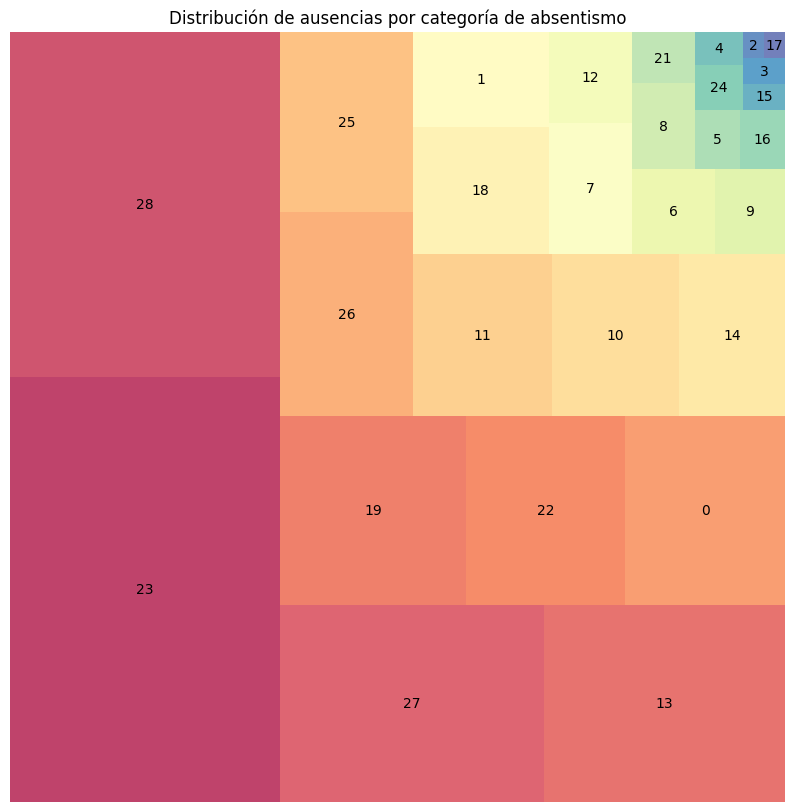

In [ ]:
# Gráfico de la variable categórica 'absence_reason'
# %pip install squarify
import squarify
absence_counts = df_ausentismo['reason_id'].value_counts()

# create a figure
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_axis_off()

squarify.plot(sizes=absence_counts.values, label=absence_counts.index, ax=ax, alpha=0.8,color=sns.color_palette("Spectral", 
                                     len(absence_counts.values)))
plt.title('Distribución de ausencias por categoría de absentismo')
plt.axis('off')
plt.show()

#### Visualización: Correlación entre variables laborales y personales

In [13]:
# Realizamos la unión de los DF ausentismo y niveles, mediante el método .merge()

df_integrado = df_ausentismo.merge(df_niveles, left_on='id', right_on='ID', how='inner')
df_integrado.head()

,id,reason_id,absence_reason,justified,Absenteeism_hours,Month_absence_num,Month_absence,Day_week,Day_of_week,Season,...,weight,height,bmi,Group,Absence_type,distance_categories,ID,work_days_absent,ab_level,level
0,14,11,Diseases of the digestive system,1,120,11,November,2,Monday,Spring,...,95,196,25,26-35,Justified,entre 10 y 20 km,14,105.50,1,Medio-Alto
1,36,13,Diseases of the musculoskeletal system and con...,1,120,4,April,4,Wednesday,Winter,...,98,178,31,46-54,Justified,entre 10 y 20 km,36,78.88,1,Medio-Alto
2,9,6,Diseases of the nervous system,1,120,7,July,3,Tuesday,Summer,...,65,172,22,55-65,Justified,entre 10 y 20 km,9,90.75,1,Medio-Alto
3,28,9,Diseases of the circulatory system,1,112,7,July,3,Tuesday,Summer,...,69,169,24,26-35,Justified,entre 21 y 30 km,28,71.38,1,Medio-Alto
4,9,12,Diseases of the skin and subcutaneous tissue,1,112,3,March,3,Tuesday,Autumn,...,65,172,22,55-65,Justified,entre 10 y 20 km,9,90.75,1,Medio-Alto


In [15]:
# Tabla cruzada para analizar los perfiles de riesgo de empleados y niveles de absentismo

perfiles= df_niveles.groupby('level')['ID'].count().sort_values(ascending=False)
perfiles

level
Bajo          370
Medio-Alto     13
Name: ID, dtype: int64

In [16]:
# Perfiles de empleados con nivel de absentismo "Muy alto, Alto y Medio"
perfiles_altos = df_niveles.loc[df_niveles['level'].isin(['Muy alto', 'Alto', 'Medio'])]
perfiles_altos['level'] = 'Alto'
perfiles_bajo = df_niveles.loc[df_niveles['level']== 'Bajo']
perfiles_alto_bajo = pd.concat([perfiles_altos, perfiles_bajo], ignore_index=True)
perfiles_alto_bajo

,ID,work_days_absent,ab_level,level
0,26,18.38,0,Bajo
1,17,15.75,0,Bajo
2,18,14.75,0,Bajo
3,7,3.75,0,Bajo
4,1,15.13,0,Bajo
...,...,...,...,...
365,382,1.00,0,Bajo
366,383,0.13,0,Bajo
367,384,0.38,0,Bajo
368,385,5.00,0,Bajo


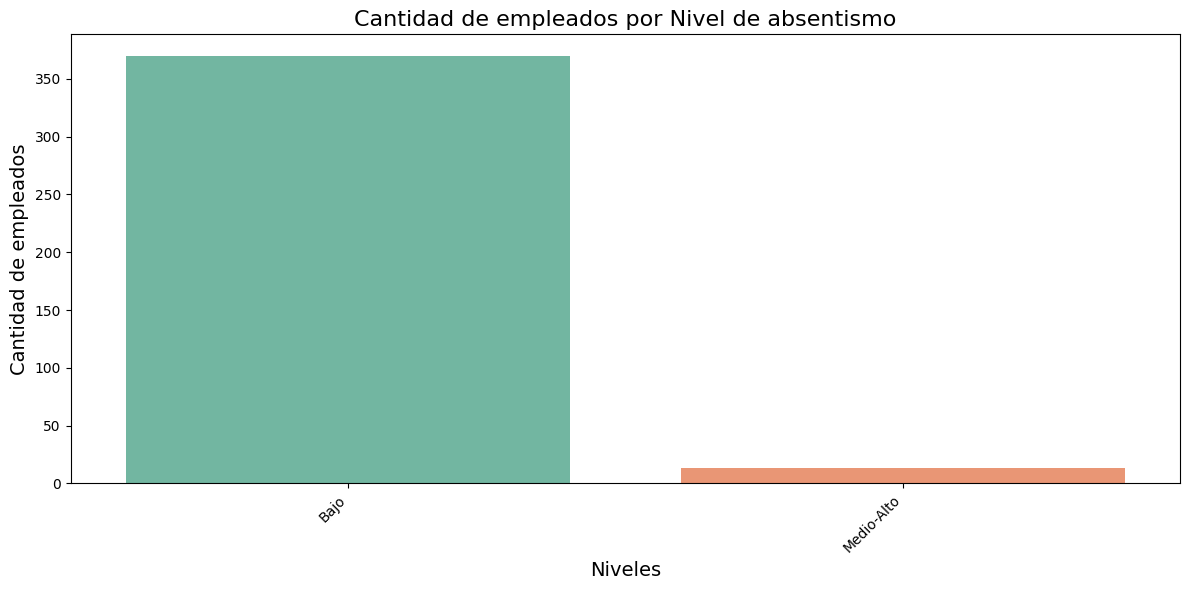

In [17]:
#Gráfico de barras para cuantificar los niveles de absentismo por cantidad de empleados
import seaborn as sns

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    x=perfiles.index,
    y=perfiles.values,
    palette='Set2',
    hue=perfiles.index,
    legend=False
)

# Añadir etiquetas y título
plt.title('Cantidad de empleados por Nivel de absentismo', fontsize=16)
plt.xlabel('Niveles', fontsize=14)
plt.ylabel('Cantidad de empleados', fontsize=14)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()

In [18]:
# Tabla cruzada para analizar los perfiles de riesgo de empleados y niveles de absentismo

cantidad_dias= df_integrado.groupby('level')['work_days_absent'].count().sort_values(ascending=False)
cantidad_dias

level
Medio-Alto    568
Bajo          538
Name: work_days_absent, dtype: int64

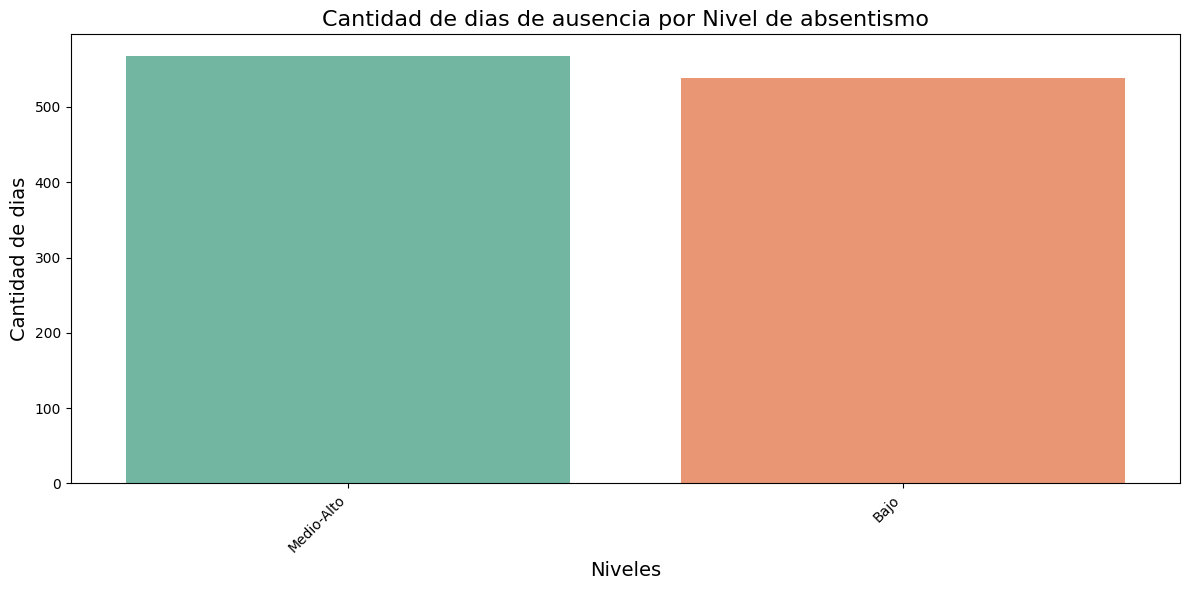

In [19]:
#Gráfico de barras para cuantificar la cantidad de dias de absentismo por niveles ordinales

import seaborn as sns

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(
    x=cantidad_dias.index,
    y=cantidad_dias.values,
    palette='Set2',
    hue=perfiles.index,
    legend=False
)

# Añadir etiquetas y título
plt.title('Cantidad de dias de ausencia por Nivel de absentismo', fontsize=16)
plt.xlabel('Niveles', fontsize=14)
plt.ylabel('Cantidad de dias', fontsize=14)

# Rotar las etiquetas del eje X para que sean legibles
plt.xticks(rotation=45, ha='right')

plt.tight_layout() # Ajustar el diseño para que todo quepa
plt.show()



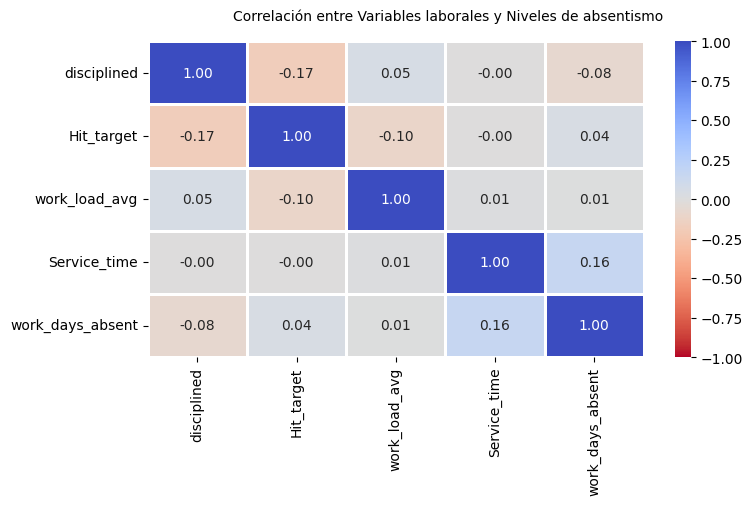

In [20]:
# Correlación de variables laborales con niveles de absentismo (work_days_absent)

# Calculamos la correlación entre las variables laborales y los niveles de absentismo.
correlation = df_integrado[['disciplined', 'Hit_target', 'work_load_avg', 'Service_time', 'work_days_absent']].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables laborales y Niveles de absentismo', fontsize=10)
plt.show()


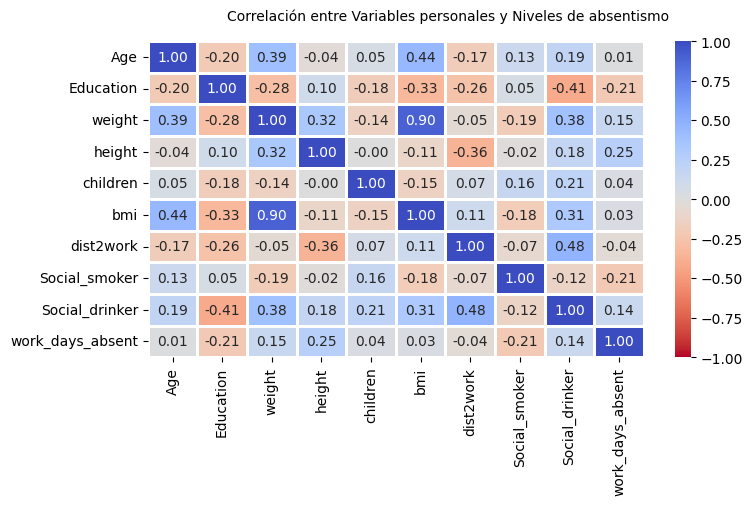

In [29]:
# Correlación de variables personales con niveles de absentismo (work_days_absent)

# Calculamos la correlación entre las variables personales y los niveles de absentismo.
correlation2 = df_integrado[['Age', 'Education', 'weight', 'height', 'children', 'bmi','dist2work','Social_smoker', 'Social_drinker','work_days_absent']].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation2, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables personales y Niveles de absentismo', fontsize=10)
plt.show()

In [33]:
# Análisis de correlación entre variables, utilizando Pearson

df_ausentismo[['Absenteeism_hours', 'Hit_target', 'Service_time', 'work_load_avg']].corr(method='pearson')

,Absenteeism_hours,Hit_target,Service_time,work_load_avg
Absenteeism_hours,1.000000,0.054144,0.057870,-0.035720
Hit_target,0.054144,1.000000,-0.004051,-0.102012
Service_time,0.057870,-0.004051,1.000000,0.013590
work_load_avg,-0.035720,-0.102012,0.013590,1.000000


In [31]:
df_filtrado = df_integrado[df_integrado['ID'].isin(perfiles_altos['ID'])]
df_filtrado['level'] = 'Alto'
df_filtrado

,id,reason_id,absence_reason,justified,Absenteeism_hours,Month_absence_num,Month_absence,Day_week,Day_of_week,Season,...,weight,height,bmi,Group,Absence_type,distance_categories,ID,work_days_absent,ab_level,level


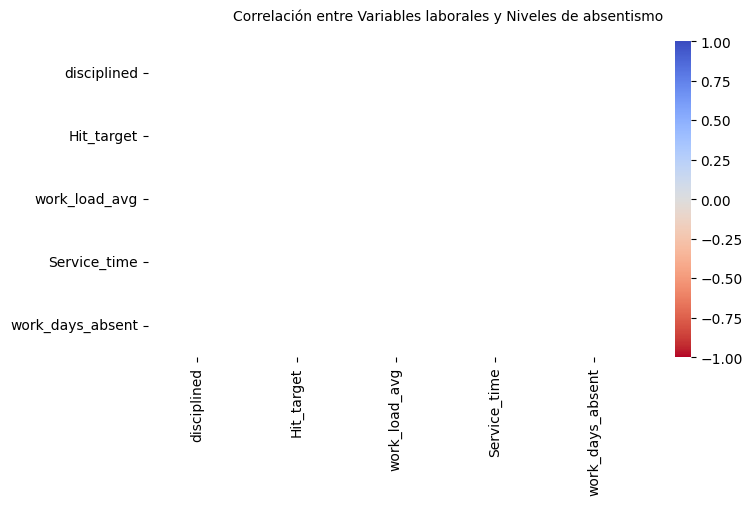

In [32]:
# Correlación de variables laborales con niveles de absentismo (Alto)

# Calculamos la correlación entre las variables laborales y los niveles de absentismo.
correlation = df_filtrado[['disciplined', 'Hit_target', 'work_load_avg', 'Service_time', 'work_days_absent']].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables laborales y Niveles de absentismo', fontsize=10)
plt.show()

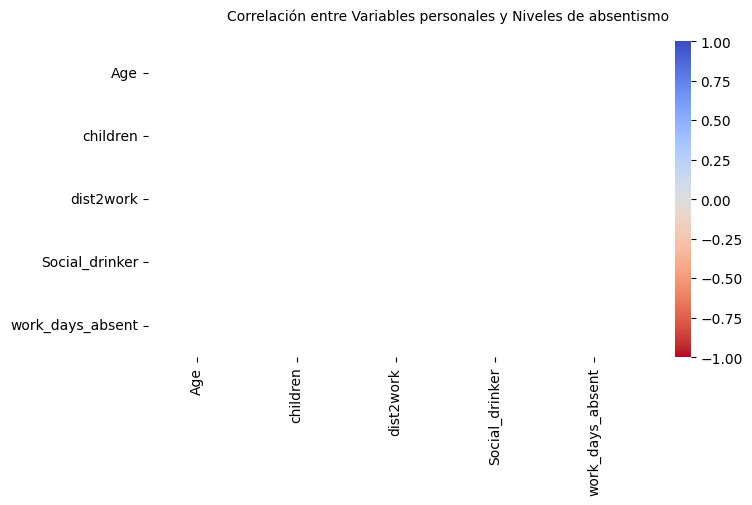

In [30]:
# Correlación de variables personales con niveles de absentismo (Alto)

# Calculamos la correlación entre las variables personales y los niveles de absentismo.
correlation2 = df_filtrado[['Age', 'children', 'dist2work', 'Social_drinker','work_days_absent']].corr()

# Creamos el mapa de calor
plt.figure(figsize=(8,4))
mapa = sns.heatmap(correlation2, 
                   cmap='coolwarm_r',
                   annot=True, 
                   fmt='.2f', 
                   vmin=-1, 
                   vmax=1, 
                   center=0, 
                   linewidths=0.8)
mapa.figure.subplots_adjust(top=0.9)
mapa.figure.suptitle('Correlación entre Variables personales y Niveles de absentismo', fontsize=10)
plt.show()

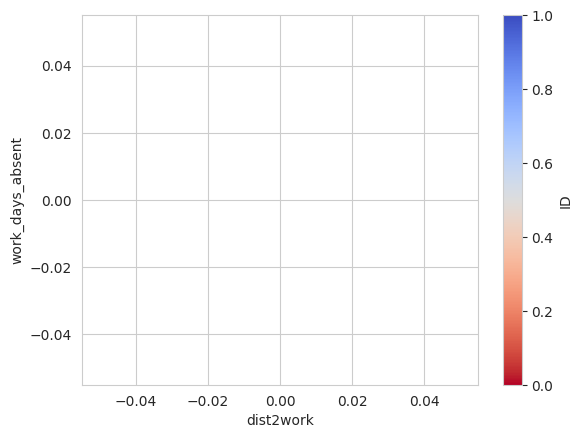

In [31]:
# Gráfico scatterplot entre variable 'dist2work' y 'work_days_absent' para perfil de absentismo (Alto)

dxw_days = df_filtrado.plot.scatter(x='dist2work',
             y='work_days_absent',
             c='ID',
             colormap='coolwarm_r')

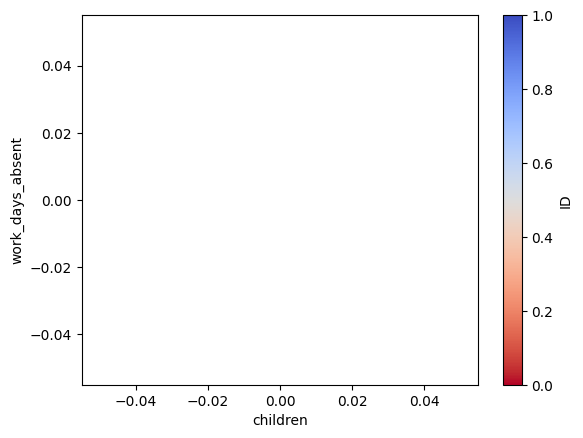

In [32]:
# Gráfico scatterplot entre variable 'children' y 'work_days_absent' para perfil de absentismo (Muy Alto/Alto)
cxw_days=df_filtrado.plot.scatter(x='children', y='work_days_absent', c='ID', colormap='coolwarm_r')


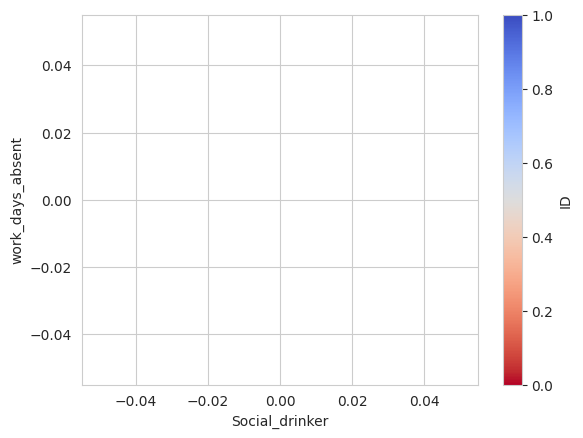

In [33]:
# Gráfico scatterplot entre variable 'children' y 'work_days_absent' para perfil de absentismo (Muy Alto/Alto)

sxw_days=df_filtrado.plot.scatter(x='Social_drinker', y='work_days_absent', c='ID', colormap='coolwarm_r')

In [34]:
df_vars = df_filtrado[['id','children', 'dist2work', 'Social_drinker','Service_time','work_load_avg','Hit_target','work_days_absent']].drop_duplicates()

,id,children,dist2work,Social_drinker,Service_time,work_load_avg,Hit_target,work_days_absent


In [35]:
df_vars.head()

,id,children,dist2work,Social_drinker,Service_time,work_load_avg,Hit_target,work_days_absent


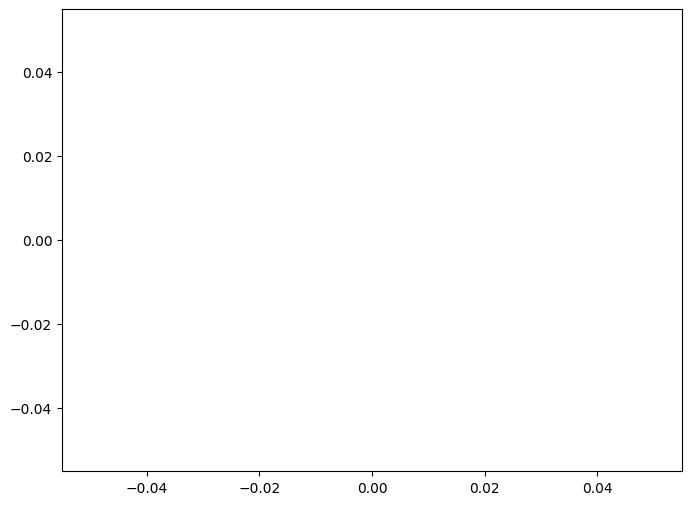

In [34]:
df_agg = df_vars.groupby('id')['work_load_avg'].agg(['mean', 'var'])
plt.figure(figsize=(8, 6))
plt.scatter(df_agg['mean'], df_agg['var'], color='blue')
max_val = max(df_agg['mean'].max(), df_agg['var'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Línea de Poisson (Varianza = Media)')


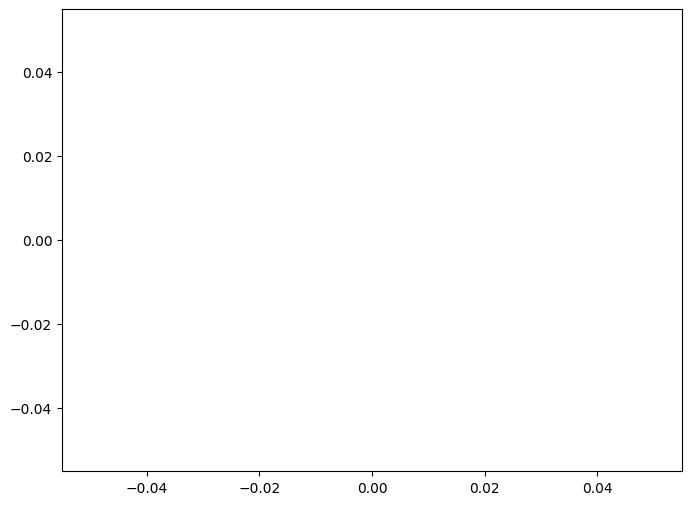

In [35]:
df_agg = df_vars.groupby('id')['Hit_target'].agg(['mean', 'var'])
plt.figure(figsize=(8, 6))
plt.scatter(df_agg['mean'], df_agg['var'], color='blue')
max_val = max(df_agg['mean'].max(), df_agg['var'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Línea de Poisson (Varianza = Media)')
